# All imports

In [5]:
%load_ext autoreload
%autoreload 2

# Standard library imports.
import os
import warnings
import numpy as np
from scipy.optimize import curve_fit, least_squares
from scipy.signal import butter, filtfilt
from scipy.spatial.transform import Rotation as Robj

# Graphics and plotting.
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Custom imports from this repo.
from mujoco_irb120.formulation.com_estimation import model_bkwd_wrench, model_fwd_wrench
from mujoco_irb120.util.plotting_helper import plot_wrench_and_tipping, plot_4vec_vs_angle, plot_2d_wrench_geometry
from mujoco_irb120.util.helper_fns import *

# %matplotlib ipympl
%matplotlib inline

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)
# Set matplotlib font size
fonts = {'size' : 20}
plt.rc('font', **fonts)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# LOAD DATA HERE:
sim_data = np.load("simulation_data.npz")

# Extract all variables from the saved file
t_hist = sim_data['t_hist']
w_hist = sim_data['w_hist']
quat_hist = sim_data['quat_hist']
ball_pose_hist = sim_data['ball_pose_hist']
sens_pose_hist = sim_data['sens_pose_hist']
con_bool_hist = sim_data['con_bool_hist']
obj_pose_hist = sim_data['obj_pose_hist']
ball_pos_hist = sim_data['ball_pos_hist']
sens_pos_hist = sim_data['sens_pos_hist']
obj_pos_hist = sim_data['obj_pos_hist']
com_GT = sim_data['com_gt']
mass_GT = sim_data['mass_gt']
mu_GT = sim_data['mu_gt']


print(f"Loaded simulation data ({len(t_hist)} timesteps)")
print(f"  Time range: {t_hist[0]:.2f} to {t_hist[-1]:.2f} s")
print(f"  Force data shape: {w_hist.shape}")
print(f"  Object position range: {obj_pos_hist.min(axis=0)} to {obj_pos_hist.max(axis=0)}")

Loaded simulation data (10141 timesteps)
  Time range: 0.25 to 10.39 s
  Force data shape: (10141, 6)
  Object position range: [ 0.57 -0.    0.05] to [0.6  0.   0.05]


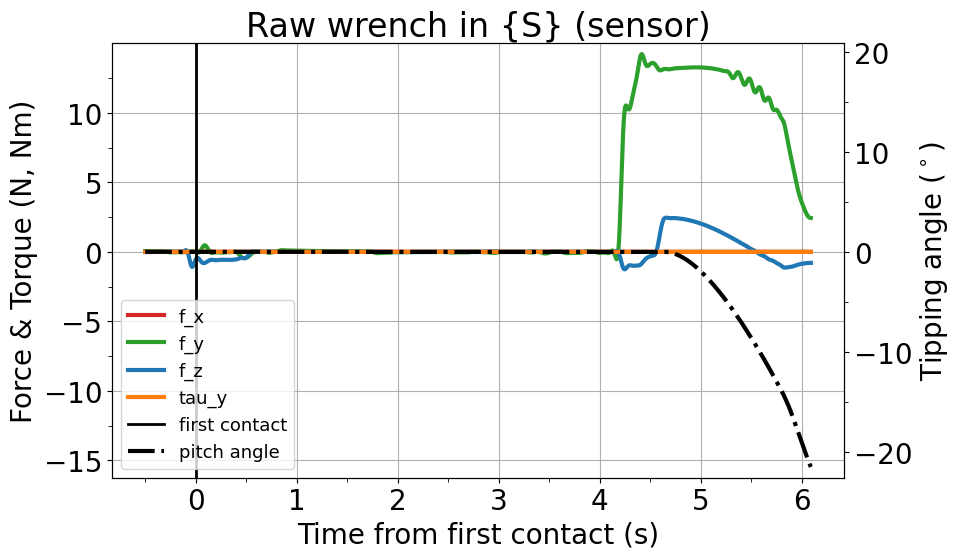

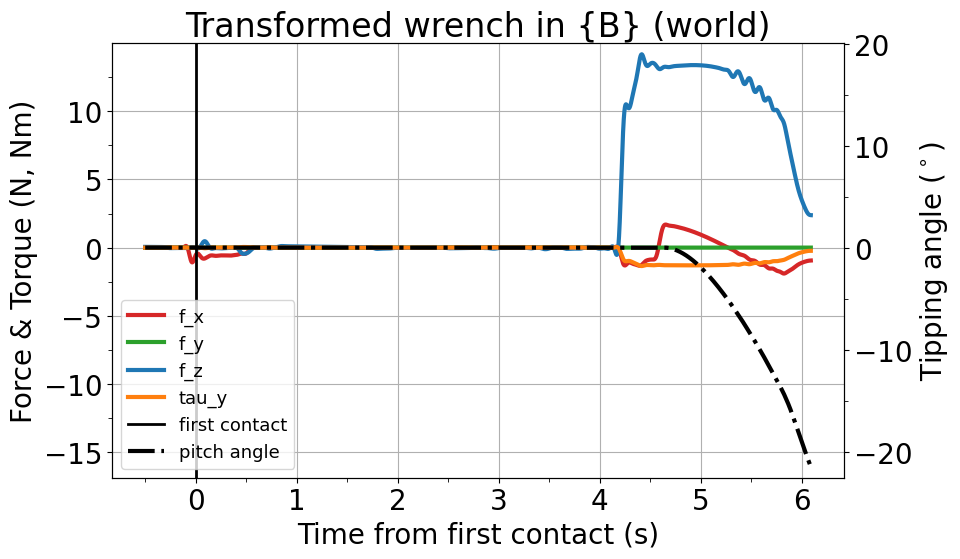

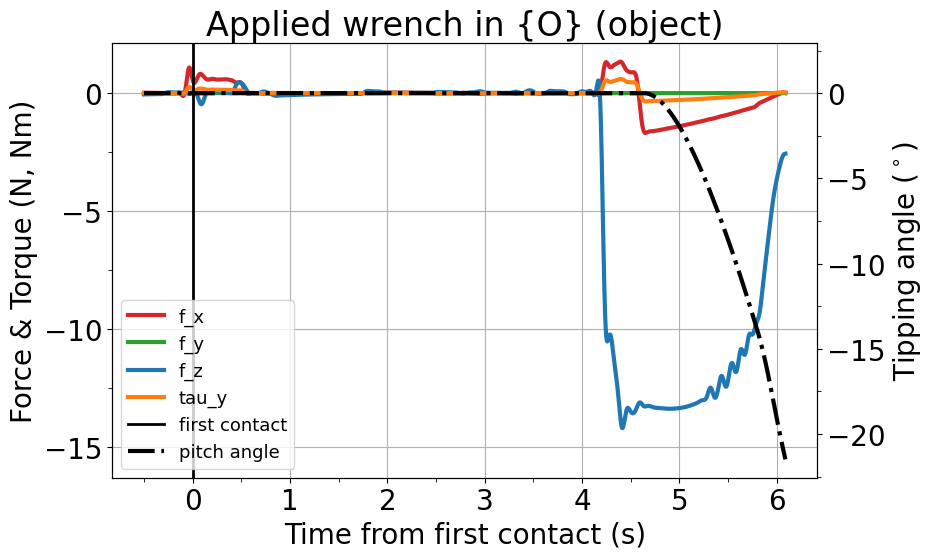

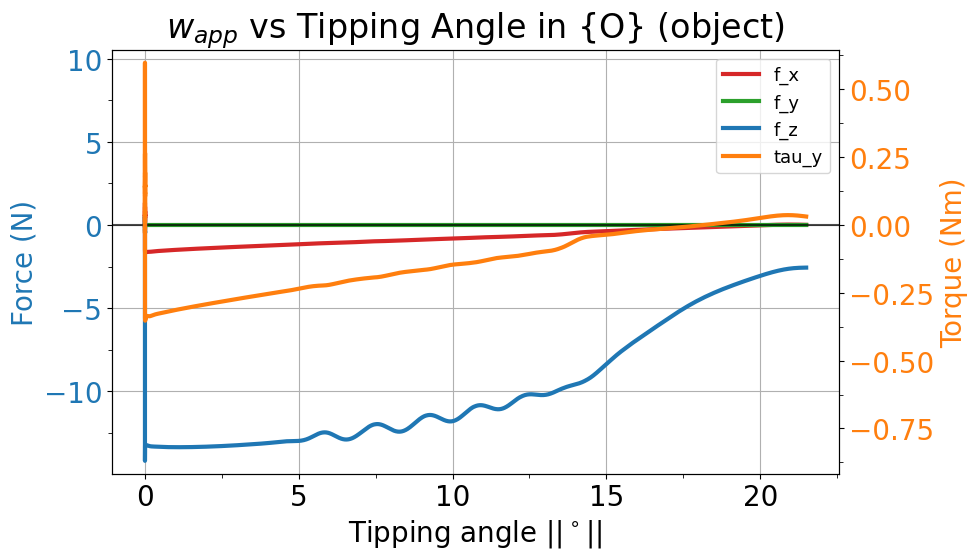

In [10]:
# Plot primary torque axis and primary tipping angle from 0.5 s before first contact
contact_mask = np.asarray(con_bool_hist).reshape(-1) # > 0.5
if not np.any(contact_mask):
    warnings.warn("No contact detected, showing all data.")

first_contact_idx = int(np.argmax(contact_mask))

# TEMP TODO: add a few indexes after contact to remove transients
first_contact_idx += 50

first_contact_time = float(t_hist[first_contact_idx])
window_start_time = max(float(t_hist[0]), first_contact_time - 0.5)
window_mask = t_hist >= window_start_time

# Filter wrench history in sensor frame {S}, then rotate to world/base frame {B}.
b, a = butter(4, 6, fs=500, btype='low')
w_meas_filt = filtfilt(b, a, w_hist, axis=0)   # (N,6) filtered, still in {S}

# UNCOMMENT TO USE RAW DATA
# w_meas_filt = w_hist.copy()

## TRIM TO CONTACT WINDOW
t_window    = t_hist[window_mask] - first_contact_time
w_S_meas    = w_meas_filt[window_mask, :]  # (N,6) in {B}, force on object
# Convert quaternion history to primary tipping angle (pitch)
quat_B      = quat_hist[window_mask, :]
pitch_B     = Robj.from_quat(quat_B).as_euler('xyz', degrees=False)[:, 1]
# Object pose, sensor pose, ball pose - all (N,4,4)
T_B_obj     = obj_pose_hist[window_mask,  :, :]
T_B_sensor  = sens_pose_hist[window_mask, :, :]
T_B_ball    = ball_pose_hist[window_mask, :, :]
p_B_ee      = T_B_ball[:, :3, 3]   # (N,3) fingertip position in world

# --- Rotate {S} -> {B} ---
_R_BS = T_B_sensor[:, :3, :3]                    # (N,3,3) Sensor orientation in world frame, i.e., rotation from sensor frame {S} to world/base frame {B}
w_B_meas = np.concatenate([
    np.einsum('nij,nj->ni', _R_BS, w_S_meas[:, :3]),
    np.einsum('nij,nj->ni', _R_BS, w_S_meas[:, 3:]),
], axis=1)                                             # (N,6) in {B}, force on object


## COMPUTE APPLIED WRENCH IN {B}
# Frames:
#   {B} = world/base frame
#   {S} = FT sensor frame  (site:sensor)
#   {O} = object frame     (site:obj_frame_site / payload_site)

# Position of finger in object frame
p_finger_B = p_B_ee - T_B_obj[:, :3, 3]                         # (N,3) relative in world frame
R_O_obj_T  = T_B_obj[:, :3, :3].transpose(0, 2, 1)              # (N,3,3)
p_finger_O = np.einsum('nij,nj->ni', R_O_obj_T, p_finger_B)     # (N,3)

# --- Back-project: applied wrench on object in {O} ---
w_O_app = model_bkwd_wrench(w_S_meas, T_B_sensor, T_B_obj, p_finger_O)  # (N,6)

plot_raw = True
save_plots_to_file = False

if plot_raw:
    # Reusable plot style for wrench + pitch
    fig, ax1, ax2 = plot_wrench_and_tipping(
        t=t_window,
        force_xyz=w_S_meas[:, :3],
        torque_primary=w_S_meas[:, 4],
        pitch_rad=pitch_B,
        torque_label='tau_y',
        force_labels=('f_x', 'f_y', 'f_z'),
        y_label='Force & Torque (N, Nm)',
        title='Raw wrench in {S} (sensor)',
        save_to_file=save_plots_to_file,
    )
    ## Plot the world wrench
    fig, ax1, ax2 = plot_wrench_and_tipping(
        t=t_window,
        force_xyz=w_B_meas[:, :3],
        torque_primary=w_B_meas[:, 4],
        pitch_rad=pitch_B,
        torque_label='tau_y',
        force_labels=('f_x', 'f_y', 'f_z'),
        y_label='Force & Torque (N, Nm)',
        title='Transformed wrench in {B} (world)',
        save_to_file=save_plots_to_file,
    )
    ## Plot the applied wrench in object frame
    fig, ax1, ax2 = plot_wrench_and_tipping(
        t=t_window,
        force_xyz=w_O_app[:, :3],
        torque_primary=w_O_app[:, 4],
        pitch_rad=pitch_B,
        torque_label='tau_y',
        force_labels=('f_x', 'f_y', 'f_z'),
        y_label='Force & Torque (N, Nm)',
        title='Applied wrench in {O} (object)',
        save_to_file=save_plots_to_file,
    )

fig, ax1 = plot_4vec_vs_angle(
    np.column_stack((w_O_app[:, 0], w_O_app[:, 1], w_O_app[:, 2], w_O_app[:, 4])),
    pitch_rad=pitch_B,
    title='$w_{app}$ vs Tipping Angle in {O} (object)',
    save_to_file=save_plots_to_file,
)

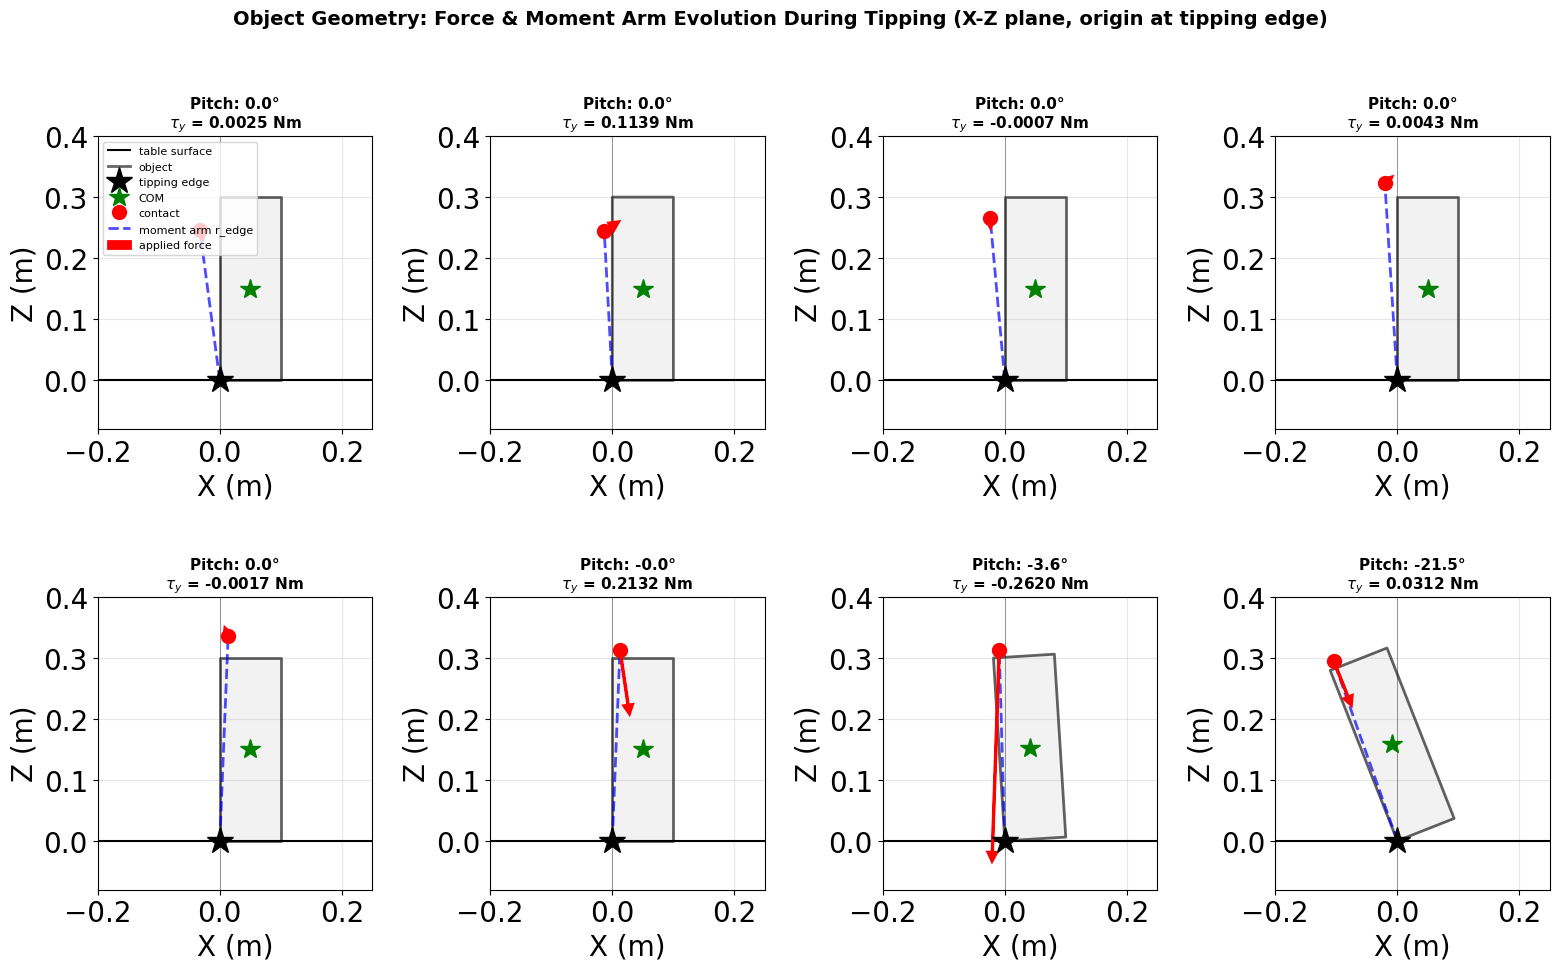


=== NEGATIVE TORQUE SPIKE ANALYSIS ===
Maximum negative spike at pitch angle: -0.0°
Torque value: -0.352732 Nm
Contact point at spike: [0.013 0.    0.312] m
Applied force at spike: [ -1.691  -0.001 -13.273] N
Moment arm (r): [-0.037  0.     0.162] m
Computed torque (r × f): [ 0.    -0.763  0.   ] Nm

The negative tau_y (clockwise when viewed from +Y) indicates:
  - The moment arm and force vectors are oriented such that their cross product
    produces a torque opposing the tipping direction (i.e., anti-tipping torque)
  - This often happens when the contact is high on the object while the force
    has a component pointing away from the object COM.


In [8]:
## 2D Geometry Visualization - visualize why torque spike happened
## Shows object orientation, contact point, force vector, and moment arm at selected angles
## Origin is at the TIPPING EDGE (pivot point during rotation in the X-Z plane)

# Extract force in object frame from the applied wrench
f_O_app = w_O_app[:, :3]

# Assume tipping edge is at the bottom front of the object
# Adjust based on your actual object geometry
p_tipping_edge_O = np.array([0.0, 0.0, 0.0])  # Pivot point at table contact

# Visualize geometry at 8 snapshots across the motion
fig, axes = plot_2d_wrench_geometry(
    pitch_rad=pitch_B,
    p_finger_O=p_finger_O,
    f_O_app=f_O_app,
    p_c_O=np.array([0.05, 0.0, 0.15]),  # COM position in object frame
    p_tipping_edge_O=p_tipping_edge_O,  # Tipping edge (pivot) position
    num_snapshots=8,
    figsize=(16, 10),
    title='Object Geometry: Force & Moment Arm Evolution During Tipping (X-Z plane, origin at tipping edge)',
    save_to_file=save_plots_to_file,
)

# Print insights about the negative torque spike
max_spike_idx = np.argmin(w_O_app[:, 4])  # Index of minimum (most negative) tau_y
spike_angle = np.rad2deg(pitch_B[max_spike_idx])
spike_magnitude = w_O_app[max_spike_idx, 4]
print(f"\n=== NEGATIVE TORQUE SPIKE ANALYSIS ===")
print(f"Maximum negative spike at pitch angle: {spike_angle:.1f}°")
print(f"Torque value: {spike_magnitude:.6f} Nm")
print(f"Contact point at spike: {p_finger_O[max_spike_idx, :]} m")
print(f"Applied force at spike: {f_O_app[max_spike_idx, :]} N")

# Compute moment arm and diagnosis
r_moment = p_finger_O[max_spike_idx, :] - np.array([0.05, 0.0, 0.15])
torque_check = np.cross(r_moment, f_O_app[max_spike_idx, :])
print(f"Moment arm (r): {r_moment} m")
print(f"Computed torque (r × f): {torque_check} Nm")
print(f"\nThe negative tau_y (clockwise when viewed from +Y) indicates:")
print(f"  - The moment arm and force vectors are oriented such that their cross product")
print(f"    produces a torque opposing the tipping direction (i.e., anti-tipping torque)")
print(f"  - This often happens when the contact is high on the object while the force")
print(f"    has a component pointing away from the object COM.")


Test the forward model (what physics occur given w_app)

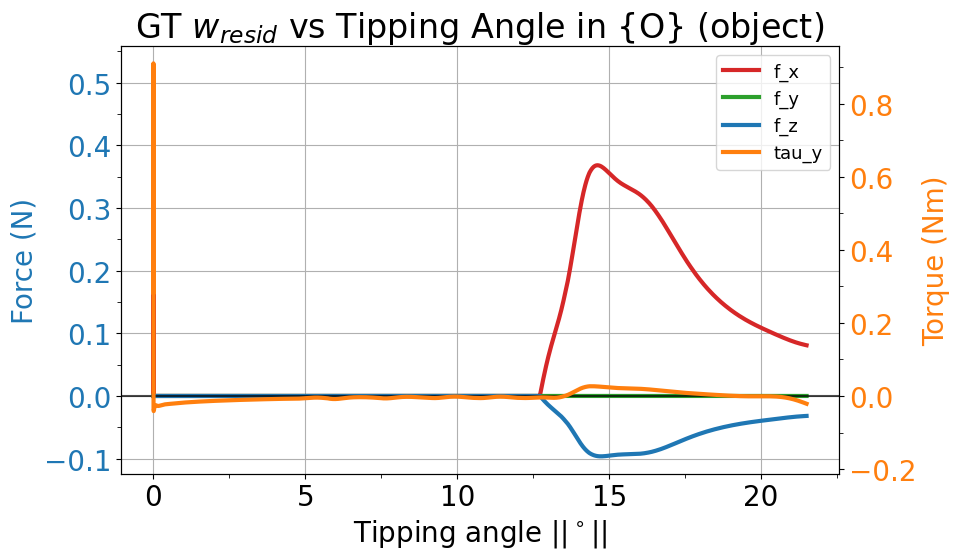

In [9]:
w_grav_pred, w_ground_pred = model_fwd_wrench(quat_to_rotvec(quat_B), com_GT, mass_GT, mu_GT, w_O_app=w_O_app)

w_fwd_pred = w_grav_pred + w_ground_pred
w_resid_pred = w_O_app + w_grav_pred + w_ground_pred

if plot_raw:
    fig, ax1, ax2 = plot_wrench_and_tipping(
        t=t_window,
        force_xyz=w_resid_pred[:, :3],
        torque_primary=w_resid_pred[:, 4],
        pitch_rad=pitch_B,
        y_label='$^Ow_{resid}$ (N, Nm)',
        title='Predicted $w_{resid}$ in {O} (object) with GT params',
        save_to_file=save_plots_to_file,
    )

# fig, ax1 = plot_4vec_vs_angle(
#     np.column_stack((w_grav_pred[:, 0], w_grav_pred[:, 1], w_grav_pred[:, 2], w_grav_pred[:, 4])),
#     pitch_rad=pitch_B,
#     title='GT $w_{grav}$ vs Tipping Angle in {O} (object)',
#     save_to_file=save_plots_to_file,
# )

# fig, ax1 = plot_4vec_vs_angle(
#     np.column_stack((w_fwd_pred[:, 0], w_fwd_pred[:, 1], w_fwd_pred[:, 2], w_fwd_pred[:, 4])),
#     pitch_rad=pitch_B,
#     title='GT $w_{fwd}$ vs Tipping Angle in {O} (object)',
#     save_to_file=save_plots_to_file,
# )

fig, ax1 = plot_4vec_vs_angle(
    np.column_stack((w_resid_pred[:, 0], w_resid_pred[:, 1], w_resid_pred[:, 2], w_resid_pred[:, 4])),
    pitch_rad=pitch_B,
    title='GT $w_{resid}$ vs Tipping Angle in {O} (object)',
    save_to_file=save_plots_to_file,
)

#### Fit only using Torque, ignore reaction

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.3020e+01                                    2.08e+00    
       1              2         2.1876e+01      1.14e+00       7.55e-01       5.00e+07    
       2              3         3.2533e+00      1.86e+01       6.03e-01       9.08e+07    
       3              4         9.6877e-02      3.16e+00       9.99e-02       2.73e+06    
       4              5         3.4823e-02      6.21e-02       2.00e-02       2.50e-02    
       5              6         3.4806e-02      1.70e-05       5.01e-04       7.85e-02    
       6              7         3.4806e-02      3.54e-11       4.40e-07       7.31e-04    
`ftol` termination condition is satisfied.
Function evaluations 7, initial cost 2.3020e+01, final cost 3.4806e-02, first-order optimality 7.31e-04.
Final cost: 3.480572e-02 | nfev=7 | njev=7 | status=2
`ftol` termination condition is satisfied.

ESTIMATED PARAMETERS FROM 

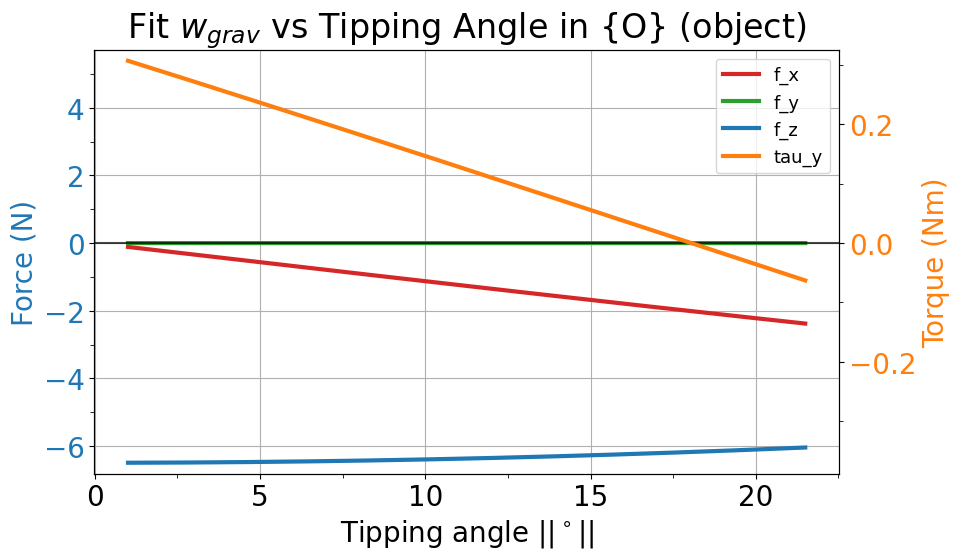

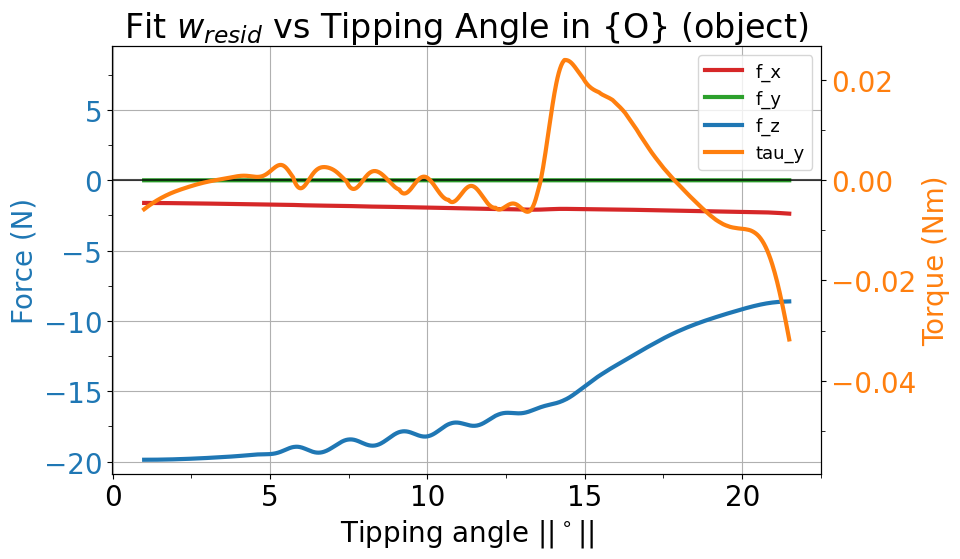

In [67]:
## Now let's curve fit using new applied wrench
# First, clean data to remove near-zero angle data since it will throw off fit (model doesn't capture theta=0)
min_angle_mag = np.deg2rad(1)
angle_mask = np.abs(pitch_B) > min_angle_mag
t_window_masked = t_window[angle_mask]
w_O_app_masked = w_O_app[angle_mask, :]
pitch_B_masked = pitch_B[angle_mask]
quat_B_masked = quat_B[angle_mask, :]

# Initial guesses for parameters
com_guess = 1.0
mass_guess = 0.01

# Use the quaternion-derived rotation vectors once so the optimizer sees the same data each call.
rv_B_masked = quat_to_rotvec(quat_B_masked)

# Initial guess for parameters
initial_guess = np.array([com_guess, mass_guess], dtype=float)
initial_bounds = ([1e-6, 1e-6], [1e6, 1e6])  # Bounds for com_z and mass

# Fit the model to the data using residuals so we can inspect optimizer progress.
# For equilibrium, the measured applied wrench should balance the modeled gravity wrench.
def model_wrapper_torque(params):
    com_z, mass = params
    com = np.array([0.05, 0.0, com_z])

    w_grav_pred, _ = model_fwd_wrench(rv_B_masked, com, mass, mu_GT) # basically ignore friction
    return w_grav_pred[:, 4] + w_O_app_masked[:, 4]

result_torque = least_squares(
    model_wrapper_torque,
    x0=initial_guess,
    bounds=initial_bounds,
    verbose=2,
    method='trf',
 )

print(f"Final cost: {result_torque.cost:.6e} | nfev={result_torque.nfev} | njev={result_torque.njev} | status={result_torque.status}")
print(result_torque.message)


pass1_z_c, pass1_mass = result_torque.x

print("\nESTIMATED PARAMETERS FROM LEAST_SQUARES:")
print(f"com_z: {pass1_z_c:.4f} m, mass: {pass1_mass:.4f} kg")
print(f"Ground truth: com_z: {com_GT[2]:.4f} m, mass: {mass_GT:.4f} kg")
print(f"Diff: com_z error: {pass1_z_c - com_GT[2]:.4f} m, mass error: {pass1_mass - mass_GT:.4f} kg")

# And plot using these estimated parameters
com_est = np.array([0.05, 0.0, pass1_z_c])
w_grav_pred, _ = model_fwd_wrench(rv_B_masked, com_est, pass1_mass, mu_GT)

w_resid_torque_only = w_O_app_masked + w_grav_pred

if plot_raw:
    fig, ax1, ax2 = plot_wrench_and_tipping(
        t=t_window_masked,
        force_xyz=w_grav_pred[:, :3],
        torque_primary=w_grav_pred[:, 4],
        pitch_rad=pitch_B_masked,
        y_label='$^{O}w_g$ (N, Nm)',
        title='Predicted $w_{grav}$ in {O} (object) with fitted params',
        save_to_file=save_plots_to_file,
    )
fig, ax1 = plot_4vec_vs_angle(
    np.column_stack((w_grav_pred[:, 0], w_grav_pred[:, 1], w_grav_pred[:, 2], w_grav_pred[:, 4])),
    pitch_rad=pitch_B_masked,
    title='Fit $w_{grav}$ vs Tipping Angle in {O} (object)',
    save_to_file=save_plots_to_file,
)
fig, ax1 = plot_4vec_vs_angle(
    np.column_stack((w_resid_torque_only[:, 0], w_resid_torque_only[:, 1], w_resid_torque_only[:, 2], w_resid_torque_only[:, 4])),
    pitch_rad=pitch_B_masked,
    title='Fit $w_{resid}$ vs Tipping Angle in {O} (object)',
    save_to_file=save_plots_to_file,
)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.6064e+02                                    5.83e+04    
       1              2         2.2770e+02      5.33e+02       7.59e-01       3.94e+08    
       2              3         5.6742e+01      1.71e+02       1.00e+00       1.34e+08    
       3              4         1.0289e+01      4.65e+01       2.87e-01       6.31e+07    
       4              5         1.0371e+00      9.25e+00       5.51e-02       1.88e+07    
       5              6         8.2658e-02      9.54e-01       1.03e-02       3.91e+06    
       6              7         3.5776e-02      4.69e-02       4.06e-03       4.50e+05    
       7              8         3.4835e-02      9.41e-04       3.69e-04       5.10e+04    
       8              9         3.4810e-02      2.50e-05       7.40e-05       1.07e+04    
       9             10         3.4808e-02      1.92e-06       2.69e-05       2.26e+03    

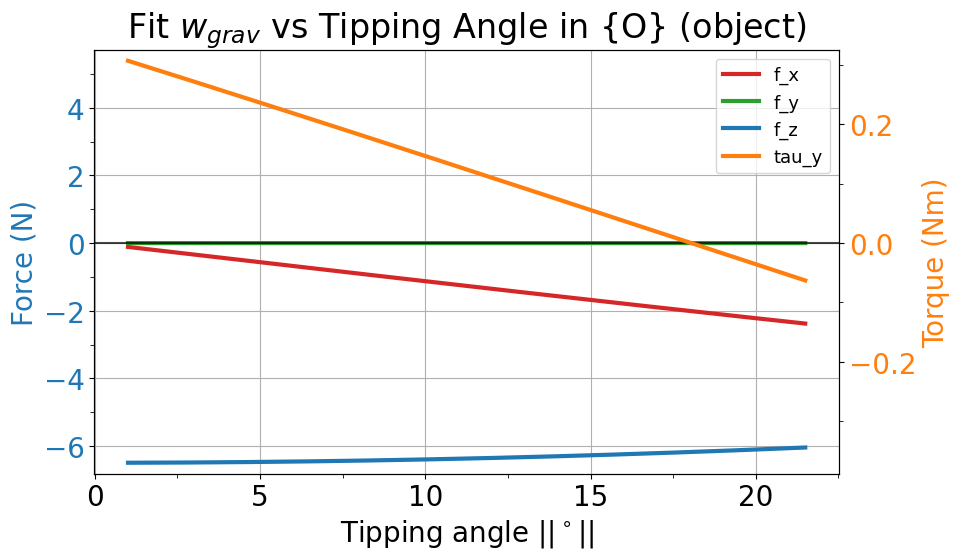

In [69]:
## Now let's curve fit using new applied wrench
# Initial guesses for parameters
com_guess = 1.0
mass_guess = 0.01
mu_guess = 1e-6

# Use the quaternion-derived rotation vectors once so the optimizer sees the same data each call.
rv_B_masked = quat_to_rotvec(quat_B_masked)

# Initial guess for parameters
initial_guess = np.array([com_guess, mass_guess, mu_guess], dtype=float)
initial_bounds = ([1e-6, 1e-6, 1e-6], [1e6, 1e6, 5.0])  # Bounds for com_z, mass, and mu

# Fit the model to the data using residuals so we can inspect optimizer progress.
# For FULL balance, applied wrench = grav+ground wrench, but must flatten residual for least_squares
def model_wrapper_full(params):
    com_z, mass, mu = params
    com = np.array([0.05, 0.0, com_z])

    w_grav_pred, w_ground_pred = model_fwd_wrench(rv_B_masked, com, mass, mu, w_O_app=w_O_app_masked)
    return (w_O_app_masked + w_grav_pred + w_ground_pred).flatten()

result_wrench = least_squares(
    model_wrapper_full,
    x0=initial_guess,
    bounds=initial_bounds,
    verbose=2,
    method='trf',
 )
print(f"Final cost: {result_wrench.cost:.6e} | nfev={result_wrench.nfev} | njev={result_wrench.njev} | status={result_wrench.status}")
print(result_wrench.message)

pass1_z_c, pass1_mass, pass1_mu = result_wrench.x

print("\nESTIMATED PARAMETERS FROM LEAST_SQUARES:")
print(f"com_z: {pass1_z_c:.4f} m, mass: {pass1_mass:.4f} kg, mu: {pass1_mu:.4f}")
print(f"Ground truth: com_z: {com_GT[2]:.4f} m, mass: {mass_GT:.4f} kg, mu: {mu_GT:.4f}")
print(f"Diff: com_z error: {pass1_z_c - com_GT[2]:.4f} m, mass error: {pass1_mass - mass_GT:.4f} kg, mu error: {pass1_mu - mu_GT:.4f}")

# And plot using these estimated parameters
com_est = np.array([0.05, 0.0, pass1_z_c])
w_grav_pred, _ = model_fwd_wrench(rv_B_masked, com_est, pass1_mass, pass1_mu)


if plot_raw:
    fig, ax1, ax2 = plot_wrench_and_tipping(
        t=t_window_masked,
        force_xyz=w_grav_pred[:, :3],
        torque_primary=w_grav_pred[:, 4],
        pitch_rad=pitch_B_masked,
        y_label='$^{O}w_g$ (N, Nm)',
        title='Predicted $w_{grav}$ in {O} (object) with fitted params',
        save_to_file=save_plots_to_file,
    )
fig, ax1 = plot_4vec_vs_angle(
    np.column_stack((w_grav_pred[:, 0], w_grav_pred[:, 1], w_grav_pred[:, 2], w_grav_pred[:, 4])),
    pitch_rad=pitch_B_masked,
    title='Fit $w_{grav}$ vs Tipping Angle in {O} (object)',
    save_to_file=save_plots_to_file,
)


In [70]:
# Back-calculate ground reaction wrench and friction coefficient
print("\n" + "="*80)
print("GROUND REACTION WRENCH ANALYSIS (Back-calculated from fitted parameters)")
print("="*80)

# Get ground reaction wrench using fit parameters
_, w_ground_fit = model_fwd_wrench(rv_B_masked, com_est, pass1_mass, pass1_mu, w_O_app=w_O_app_masked)

# Extract normal and friction forces
# Object frame: x-forward, y-left, z-up; gravity along -z, so normal force is positive z
f_ground_fit = w_ground_fit[:, :3]  # (N_samples, 3) ground reaction force
tau_ground_fit = w_ground_fit[:, 3:]  # (N_samples, 3) ground reaction torque

# Normal force is positive Z component (reaction to gravity)
f_normal_fit = f_ground_fit[:, 2]  # (N_samples,)

# Friction forces are in X-Y plane
f_friction_fit = np.linalg.norm(f_ground_fit[:, :2], axis=1)  # (N_samples,)

# Calculate implied friction coefficient at each sample
# Avoid division by zero for very small normal forces
mu_implied = np.zeros_like(f_normal_fit)
valid_contact = np.abs(f_normal_fit) > 1e-6
mu_implied[valid_contact] = f_friction_fit[valid_contact] / np.abs(f_normal_fit[valid_contact])

# Statistics on the implied friction coefficient
mu_implied_mean = np.mean(mu_implied[valid_contact])
mu_implied_std = np.std(mu_implied[valid_contact])
mu_implied_median = np.median(mu_implied[valid_contact])

print(f"\nGround Reaction Analysis (N={np.sum(valid_contact)} samples with |F_normal| > 1e-6):")
print(f"  Normal force (F_z): {np.mean(f_normal_fit[valid_contact]):.4f} ± {np.std(f_normal_fit[valid_contact]):.4f} N")
print(f"  Friction magnitude: {np.mean(f_friction_fit[valid_contact]):.4f} ± {np.std(f_friction_fit[valid_contact]):.4f} N")
print(f"  Implied mu (friction / normal): {mu_implied_mean:.4f} ± {mu_implied_std:.4f} (median: {mu_implied_median:.4f})")
print(f"\nComparison:")
print(f"  Fitted mu (from least_squares):  {pass1_mu:.4f}")
print(f"  Implied mu (from back-calced):   {mu_implied_mean:.4f}")
print(f"  Ground truth mu:                 {mu_GT:.4f}")
print(f"  Difference (fitted - implied):   {pass1_mu - mu_implied_mean:.4f}")
print(f"  Difference (fitted - GT):        {pass1_mu - float(mu_GT):.4f}")
print(f"  Difference (implied - GT):       {mu_implied_mean - float(mu_GT):.4f}")



GROUND REACTION WRENCH ANALYSIS (Back-calculated from fitted parameters)

Ground Reaction Analysis (N=1201 samples with |F_normal| > 1e-6):
  Normal force (F_z): 17.0399 ± 3.3778 N
  Friction magnitude: 1.8874 ± 0.2049 N
  Implied mu (friction / normal): 0.1203 ± 0.0488 (median: 0.0998)

Comparison:
  Fitted mu (from least_squares):  0.1233
  Implied mu (from back-calced):   0.1203
  Ground truth mu:                 0.1000
  Difference (fitted - implied):   0.0030
  Difference (fitted - GT):        0.0233
  Difference (implied - GT):       0.0203


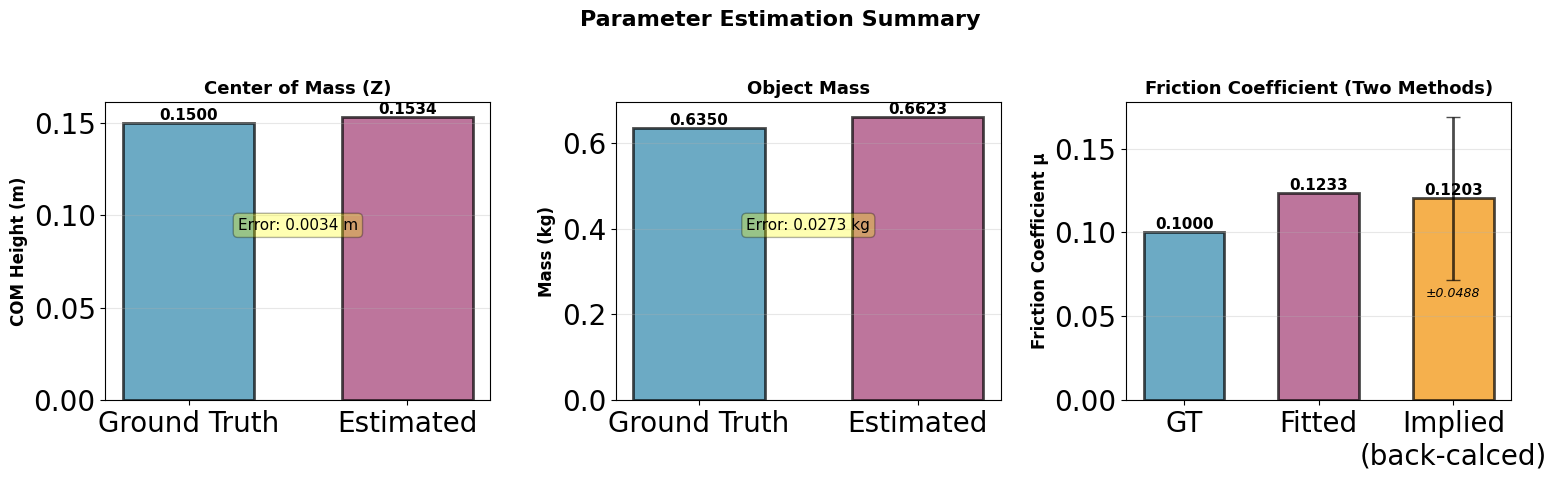


SUMMARY: Parameter Estimation Summary saved to 'parameter_estimation_summary.png'

Quick Reference:
  COM-Z:     0.153444 m  (GT: 0.150000, error: 0.003444)
  Mass:      0.662340 kg (GT: 0.635000, error: 0.027340)
  Friction:  Fitted μ = 0.123319, Implied μ = 0.120312 ± 0.048797
             Ground truth μ = 0.100000


In [74]:
# Visualize parameter estimation results - single row per parameter
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Parameter Estimation Summary', fontsize=16, fontweight='bold')

# Color scheme
color_gt = '#2E86AB'      # Ground truth (blue)
color_est = '#A23B72'     # Estimated (purple)
color_implied = '#F18F01' # Implied (orange)

# ===== COM-Z =====
ax = axes[0]
categories_com = ['Ground Truth', 'Estimated']
values_com = [float(com_GT[2]), pass1_z_c]
colors_com = [color_gt, color_est]
bars_com = ax.bar(categories_com, values_com, color=colors_com, alpha=0.7, edgecolor='black', linewidth=2, width=0.6)
ax.set_ylabel('COM Height (m)', fontsize=12, fontweight='bold')
ax.set_title('Center of Mass (Z)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar, val in zip(bars_com, values_com):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
# Add error annotation
error_com = pass1_z_c - float(com_GT[2])
ax.text(0.5, max(values_com) * 0.6, f'Error: {error_com:.4f} m', 
        ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# ===== MASS =====
ax = axes[1]
categories_mass = ['Ground Truth', 'Estimated']
values_mass = [float(mass_GT), pass1_mass]
colors_mass = [color_gt, color_est]
bars_mass = ax.bar(categories_mass, values_mass, color=colors_mass, alpha=0.7, edgecolor='black', linewidth=2, width=0.6)
ax.set_ylabel('Mass (kg)', fontsize=12, fontweight='bold')
ax.set_title('Object Mass', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar, val in zip(bars_mass, values_mass):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
# Add error annotation
error_mass = pass1_mass - float(mass_GT)
ax.text(0.5, max(values_mass) * 0.6, f'Error: {error_mass:.4f} kg', 
        ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# ===== FRICTION COEFFICIENT (Two methods) =====
ax = axes[2]
categories_mu = ['GT', 'Fitted', 'Implied\n(back-calced)']
values_mu = [float(mu_GT), pass1_mu, mu_implied_mean]
colors_mu = [color_gt, color_est, color_implied]
bars_mu = ax.bar(categories_mu, values_mu, color=colors_mu, alpha=0.7, edgecolor='black', linewidth=2, width=0.6)
ax.set_ylabel('Friction Coefficient μ', fontsize=12, fontweight='bold')
ax.set_title('Friction Coefficient (Two Methods)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars_mu, values_mu)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    # Add uncertainty band for implied (std)
    if i == 2:
        ax.errorbar(bar.get_x() + bar.get_width()/2., val, yerr=mu_implied_std, fmt='none', 
                    ecolor='black', capsize=5, linewidth=2, alpha=0.7)
        ax.text(bar.get_x() + bar.get_width()/2., val - mu_implied_std - 0.01,
                f'±{mu_implied_std:.4f}', ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('parameter_estimation_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("SUMMARY: Parameter Estimation Summary saved to 'parameter_estimation_summary.png'")
print("="*80)
print(f"\nQuick Reference:")
print(f"  COM-Z:     {pass1_z_c:.6f} m  (GT: {float(com_GT[2]):.6f}, error: {error_com:.6f})")
print(f"  Mass:      {pass1_mass:.6f} kg (GT: {float(mass_GT):.6f}, error: {error_mass:.6f})")
print(f"  Friction:  Fitted μ = {pass1_mu:.6f}, Implied μ = {mu_implied_mean:.6f} ± {mu_implied_std:.6f}")
print(f"             Ground truth μ = {float(mu_GT):.6f}")
print("="*80)
